## 1 Overview

### 1.1 Problem Statement

### 1.2 About Dataset

1. `Request id`: Trip request id.
2. `Pickup point`: Pickup point of trip.
   - `Airport`: Trip picked up from Airport to City.
   - `City`: Trip picked up from City to Airport.
3. `Driver id`: Driver's id number.
4. `Status`: Three types of trip status.
   - `Trip Completed`
   - `Cancelled`
   - `No Cars Available`
5. `Request timestamp`: Date and time when trip request was raised.
6. `Drop timestamp`: Date and time when customer was dropped at location.

### 1.3 Objective

Perform Root Cause Analysis (RCA) to identify the root cause of trip cancellation.

To achieve this objective perform:

1. Exploratory data analysis on dataset.
2. Perform Feature Engineering.
3. Define and analyze Metrics.

## 2 Setup

### 2.1 Libraries

#### Import Libraries

In [1]:
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
import seaborn as sns

#### Configure Libraries

In [2]:
# Configure NumPy.
np.random.seed(42)

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

#### Constants and Helper Functions

In [3]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

### 2.3 Dataset

#### Import dataset

In [4]:
ub_df = pd.read_csv("data/uber-data.csv")

row_count, col_count = ub_df.shape
display(ub_df.sample(5, random_state=16))
print(f"Dataset has {row_count} rows and {col_count} columns.")

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
2898,5208,Airport,20.0,Cancelled,14-07-2016 20:55:57,NaN
326,1478,City,33.0,Trip Completed,12/7/2016 5:16,12/7/2016 6:13
6649,6552,Airport,NaN,No Cars Available,15-07-2016 21:08:54,NaN
1902,6007,City,199.0,Trip Completed,15-07-2016 12:15:42,15-07-2016 13:03:40
4557,1257,Airport,NaN,No Cars Available,11/7/2016 21:55,NaN


Dataset has 6745 rows and 6 columns.


### 2.4 Data Profiling

In [5]:
ub_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 316.3 KB


In [6]:
ub_df.rename(
    columns={
        "Request id": "req_id",
        "Pickup point": "pickup",
        "Driver id": "dvr_id",
        "Status": "status",
        "Request timestamp": "req_dt",
        "Drop timestamp": "drp_dt",
    },
    inplace=True,
)

In [7]:
ub_df["req_id"].nunique()

6745

In [8]:
# ub_df.drop(columns="req_id", inplace=True)

In [9]:
ub_df["pickup"].value_counts()

pickup
City       3507
Airport    3238
Name: count, dtype: int64

In [10]:
ub_df["status"].value_counts()

status
Trip Completed       2831
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

## 3 Data Wrangling

### 3.1 Duplicates check

In [11]:
dup_count = ub_df.duplicated().sum()
print(f"Dataset has {dup_count} duplicate rows.")

Dataset has 0 duplicate rows.


### 3.2 Handling Null values

In [12]:
ub_df.isna().sum()

req_id       0
pickup       0
dvr_id    2650
status       0
req_dt       0
drp_dt    3914
dtype: int64

In [13]:
mask = ub_df["dvr_id"].isna()
ub_df[mask]["status"].value_counts()

status
No Cars Available    2650
Name: count, dtype: int64

In [14]:
mask = ub_df["drp_dt"].isna()
ub_df[mask]["status"].value_counts()

status
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

### 3.3 Type Casting

#### request/drop timestamps to date-time object

In [15]:
ub_df.loc[[326, 1902, 4557], ["req_dt", "drp_dt"]]

,req_dt,drp_dt
326,12/7/2016 5:16,12/7/2016 6:13
1902,15-07-2016 12:15:42,15-07-2016 13:03:40
4557,11/7/2016 21:55,NaN


In [16]:
ub_df["req_dt"] = pd.to_datetime(ub_df["req_dt"], format="mixed", dayfirst=True)
ub_df["drp_dt"] = pd.to_datetime(ub_df["drp_dt"], format="mixed", dayfirst=True)

In [17]:
ub_df.loc[[326, 1902, 4557], ["req_dt", "drp_dt"]]

,req_dt,drp_dt
326,2016-07-12 05:16:00,2016-07-12 06:13:00
1902,2016-07-15 12:15:42,2016-07-15 13:03:40
4557,2016-07-11 21:55:00,NaT


#### Status to category

In [18]:
status_map = {
    "Cancelled": "Canceled",
    "No Cars Available": "Unavailable",
    "Trip Completed": "Completed",
}
status_order = list(status_map.values())

# Convert 'status' column to a categorical type in the specified order.
ub_df["status"] = pd.Categorical(
    ub_df["status"].map(status_map),
    categories=status_order,
    ordered=True,
)

ub_df["status"].value_counts()

status
Completed      2831
Unavailable    2650
Canceled       1264
Name: count, dtype: int64

> **Note**:
>
> The spelling mistake in trip status "Cancelled" was also corrected to "Canceled" while mapping.

#### Pickup type to category

In [19]:
pickup_map = {
    "Airport": "Airport to City",
    "City": "City to Airport",
}

# Convert 'pickup' column to a categorical type.
ub_df["pickup"] = ub_df["pickup"].map(pickup_map).astype("category")
ub_df["pickup"].value_counts()

pickup
City to Airport    3507
Airport to City    3238
Name: count, dtype: int64

### 3.4 Data Validation

In [20]:
mask = ub_df["drp_dt"] < ub_df["req_dt"]
ub_df[mask]

,req_id,pickup,dvr_id,status,req_dt,drp_dt


In [21]:
mask = ub_df["drp_dt"].isna()
ub_df[mask]["status"].value_counts()

status
Unavailable    2650
Canceled       1264
Completed         0
Name: count, dtype: int64

In [22]:
mask = ub_df["dvr_id"].isna()
ub_df[mask]["status"].value_counts()

status
Unavailable    2650
Canceled          0
Completed         0
Name: count, dtype: int64

## 4 Feature Engineering

### 4.1 Create New Features

#### Extract features from request date-time

In [23]:
ub_df["req_year"] = ub_df["req_dt"].dt.year.astype("Int32")
ub_df["req_month"] = ub_df["req_dt"].dt.month.astype("Int32")
ub_df["req_date"] = ub_df["req_dt"].dt.day.astype("Int32")
ub_df["req_wday"] = ub_df["req_dt"].dt.day_name().astype("category")
ub_df["req_hour"] = ub_df["req_dt"].dt.hour.astype("Int32")
ub_df["req_min"] = ub_df["req_dt"].dt.minute.astype("Int32")

ub_df[["req_dt", "req_year", "req_month", "req_date", "req_wday", "req_hour", "req_min"]].sample(3)

,req_dt,req_year,req_month,req_date,req_wday,req_hour,req_min
2531,2016-07-13 03:55:10,2016,7,13,Wednesday,3,55
4591,2016-07-11 23:30:00,2016,7,11,Monday,23,30
4127,2016-07-11 03:07:00,2016,7,11,Monday,3,7


#### Extract features from drop date-time

In [24]:
ub_df["drp_year"] = ub_df["drp_dt"].dt.year.astype("Int32")
ub_df["drp_month"] = ub_df["drp_dt"].dt.month.astype("Int32")
ub_df["drp_date"] = ub_df["drp_dt"].dt.day.astype("Int32")
ub_df["drp_wday"] = ub_df["drp_dt"].dt.day_name()
ub_df["drp_hour"] = ub_df["drp_dt"].dt.hour.astype("Int32")
ub_df["drp_min"] = ub_df["drp_dt"].dt.minute.astype("Int32")

ub_df[["drp_dt", "drp_year", "drp_month", "drp_date", "drp_wday", "drp_hour", "drp_min"]].sample(3)

,drp_dt,drp_year,drp_month,drp_date,drp_wday,drp_hour,drp_min
3858,NaT,<NA>,<NA>,<NA>,NaN,<NA>,<NA>
833,2016-07-13 21:43:20,2016,7,13,Wednesday,21,43
3288,NaT,<NA>,<NA>,<NA>,NaN,<NA>,<NA>


#### New Feature 'Time Difference'

In [25]:
ub_df["time_diff"] = ub_df["drp_dt"] - ub_df["req_dt"]
ub_df[["req_dt", "drp_dt", "time_diff"]].sample(3)

,req_dt,drp_dt,time_diff
5139,2016-07-13 02:37:05,NaT,NaT
6165,2016-07-15 00:09:09,NaT,NaT
4852,2016-07-12 18:20:00,NaT,NaT


#### New Feature Working Hours

In [26]:
hour_bins = [-1, 4, 8, 18, 23]
day_type = [
    "Mid Night",  # [12 AM, 4 AM]
    "Early Morning",  # [5 AM, 8 AM]
    "Working Hours",  # [9 AM, 6 PM]
    "Night",  # [7 PM , 11 PM]
]

ub_df["day_type"] = pd.cut(ub_df["req_hour"], bins=hour_bins, labels=day_type)

ub_df[["req_hour", "day_type"]].sample(3)

,req_hour,day_type
4389,18,Working Hours
3911,9,Working Hours
2476,6,Early Morning


### 3.4 Final DataFrame

In [27]:
ub_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype          
---  ------     --------------  -----          
 0   req_id     6745 non-null   int64          
 1   pickup     6745 non-null   category       
 2   dvr_id     4095 non-null   float64        
 3   status     6745 non-null   category       
 4   req_dt     6745 non-null   datetime64[us] 
 5   drp_dt     2831 non-null   datetime64[us] 
 6   req_year   6745 non-null   Int32          
 7   req_month  6745 non-null   Int32          
 8   req_date   6745 non-null   Int32          
 9   req_wday   6745 non-null   category       
 10  req_hour   6745 non-null   Int32          
 11  req_min    6745 non-null   Int32          
 12  drp_year   2831 non-null   Int32          
 13  drp_month  2831 non-null   Int32          
 14  drp_date   2831 non-null   Int32          
 15  drp_wday   2831 non-null   str            
 16  drp_hour   2831 non-null   Int32   

### 4.2 Define New Metrics

1. Demand-Supply-Gap
2. Availability rate
3. Cancellation rate

#### 1 Demand-Supply-Gap

##### Case #1

In [28]:
d = 100
s = 10
(d - s) / d

0.9

##### Case #2

In [29]:
d = 100
s = 100
(d - s) / d

0.0

##### Case #3

In [30]:
d = 10
s = 100
(d - s) / d

-9.0

#### 2 Availability rate

#### 3 Cancellation rate

In [31]:
def caculate_metrics(df: pd.DataFrame, for_col: str):
    """
    Function to compute metrics:
        1. Demand Supply Gap.
        2. Availability rate.
        3. Cancellation rate.
    """
    return (
        df.groupby(by=for_col)
        .agg(
            demand=("req_id", "count"),
            supply=("status", lambda x: (x == "Completed").sum()),
            avblty_count=("status", lambda x: (x != "Unavailable").sum()),
            cancel_count=("status", lambda x: (x == "Canceled").sum()),
        )
        .assign(
            ds_gap=lambda df: ((df["demand"] - df["supply"]) / df["demand"]).round(4),
            avblty_rate=lambda df: (df["avblty_count"] / df["demand"]).round(4),
            cancel_rate=lambda df: (df["cancel_count"] / df["demand"]).round(4),
        )
        .reset_index()
    )

### 4.3 Crate Features for Metrics

#### 1 Daily Metrics

In [32]:
dlm_df = caculate_metrics(ub_df, "req_date")
dlm_df

,req_date,demand,supply,avblty_count,cancel_count,ds_gap,avblty_rate,cancel_rate
0,11,1367,601,863,262,0.5604,0.6313,0.1917
1,12,1307,562,802,240,0.5700,0.6136,0.1836
2,13,1337,577,847,270,0.5684,0.6335,0.2019
3,14,1353,530,782,252,0.6083,0.5780,0.1863
4,15,1381,561,801,240,0.5938,0.5800,0.1738


#### 2 Weekly Metrics

In [33]:
wkm_df = caculate_metrics(ub_df, "req_wday")

wd_cat_type = CategoricalDtype(categories=weekdays, ordered=True)
wkm_df["req_wday"] = wkm_df["req_wday"].astype(wd_cat_type)
wkm_df = wkm_df.sort_values(by="req_wday")

wkm_df

,req_wday,demand,supply,avblty_count,cancel_count,ds_gap,avblty_rate,cancel_rate
1,Monday,1367,601,863,262,0.5604,0.6313,0.1917
3,Tuesday,1307,562,802,240,0.5700,0.6136,0.1836
4,Wednesday,1337,577,847,270,0.5684,0.6335,0.2019
2,Thursday,1353,530,782,252,0.6083,0.5780,0.1863
0,Friday,1381,561,801,240,0.5938,0.5800,0.1738


#### 2 Hourly Metrics

In [34]:
hrm_df = caculate_metrics(ub_df, "req_hour")
hrm_df

,req_hour,demand,supply,avblty_count,cancel_count,ds_gap,avblty_rate,cancel_rate
0,0,99,40,43,3,0.5960,0.4343,0.0303
1,1,85,25,29,4,0.7059,0.3412,0.0471
2,2,99,37,42,5,0.6263,0.4242,0.0505
3,3,92,34,36,2,0.6304,0.3913,0.0217
4,4,203,78,129,51,0.6158,0.6355,0.2512
5,5,445,185,361,176,0.5843,0.8112,0.3955
6,6,398,167,312,145,0.5804,0.7839,0.3643
7,7,406,174,343,169,0.5714,0.8448,0.4163
8,8,423,155,333,178,0.6336,0.7872,0.4208
9,9,431,173,348,175,0.5986,0.8074,0.4060


### 4.4 Final DataFrame

In [35]:
ub_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype          
---  ------     --------------  -----          
 0   req_id     6745 non-null   int64          
 1   pickup     6745 non-null   category       
 2   dvr_id     4095 non-null   float64        
 3   status     6745 non-null   category       
 4   req_dt     6745 non-null   datetime64[us] 
 5   drp_dt     2831 non-null   datetime64[us] 
 6   req_year   6745 non-null   Int32          
 7   req_month  6745 non-null   Int32          
 8   req_date   6745 non-null   Int32          
 9   req_wday   6745 non-null   category       
 10  req_hour   6745 non-null   Int32          
 11  req_min    6745 non-null   Int32          
 12  drp_year   2831 non-null   Int32          
 13  drp_month  2831 non-null   Int32          
 14  drp_date   2831 non-null   Int32          
 15  drp_wday   2831 non-null   str            
 16  drp_hour   2831 non-null   Int32   

In [36]:
ub_df.head()

,req_id,pickup,dvr_id,status,req_dt,drp_dt,req_year,req_month,req_date,req_wday,req_hour,req_min,drp_year,drp_month,drp_date,drp_wday,drp_hour,drp_min,time_diff,day_type
0,619,Airport to City,1.0,Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,2016,7,11,Monday,11,51,2016,7,11,Monday,13,0,0 days 01:09:00,Working Hours
1,867,Airport to City,1.0,Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,2016,7,11,Monday,17,57,2016,7,11,Monday,18,47,0 days 00:50:00,Working Hours
2,1807,City to Airport,1.0,Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,2016,7,12,Tuesday,9,17,2016,7,12,Tuesday,9,58,0 days 00:41:00,Working Hours
3,2532,Airport to City,1.0,Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,2016,7,12,Tuesday,21,8,2016,7,12,Tuesday,22,3,0 days 00:55:00,Night
4,3112,City to Airport,1.0,Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016,7,13,Wednesday,8,33,2016,7,13,Wednesday,9,25,0 days 00:52:31,Early Morning


In [37]:
ub_df["req_year"].value_counts(), ub_df["drp_year"].value_counts()

(req_year
 2016    6745
 Name: count, dtype: Int64,
 drp_year
 2016    2831
 Name: count, dtype: Int64)

In [38]:
ub_df["req_month"].value_counts(), ub_df["drp_month"].value_counts()

(req_month
 7    6745
 Name: count, dtype: Int64,
 drp_month
 7    2831
 Name: count, dtype: Int64)

In [39]:
# ub_df["req_hour"].value_counts().sort_index()

## 5 Univariate Analysis

### 5.1 Categorical Features

#### Feature Status

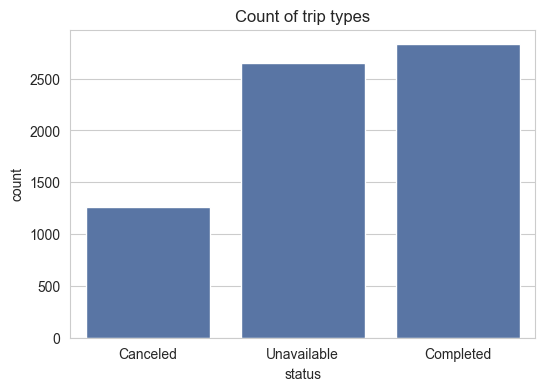

In [102]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="status")
plt.title("Count of trip types")
plt.show()

#### Feature Pickup Point

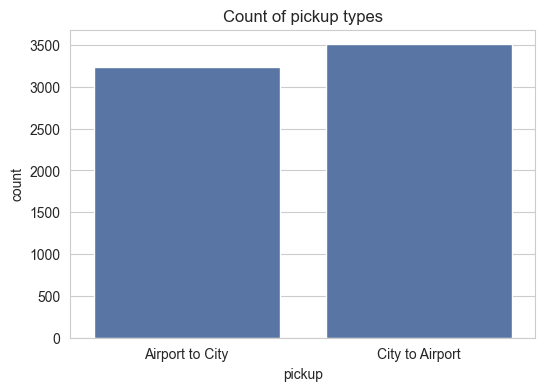

In [103]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="pickup")
plt.title("Count of pickup types")
plt.show()

### 5.2 Numerical Features

#### Feature Request Date

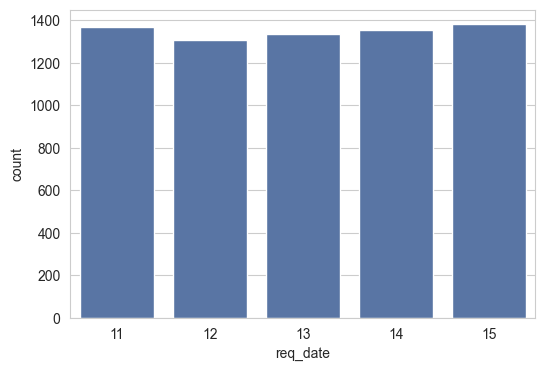

In [42]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="req_date")
plt.show()

#### Feature Request Weekday

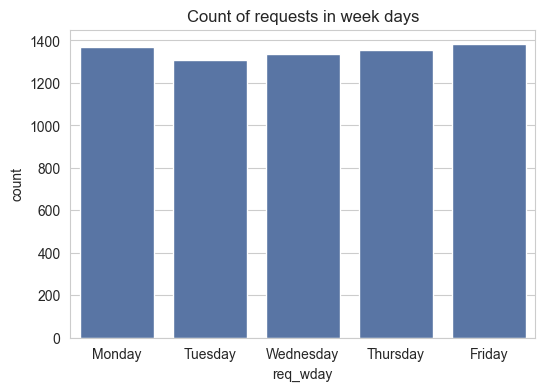

In [106]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="req_wday", order=weekdays)
plt.title("Count of requests in week days")
plt.show()

#### Feature Request Hour

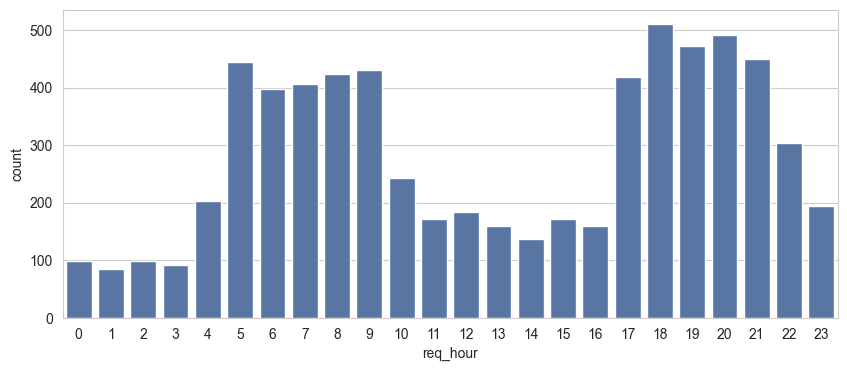

In [44]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_hour")
plt.title("Count of requests in 24 hours")
plt.show()

#### Feature Drop Date

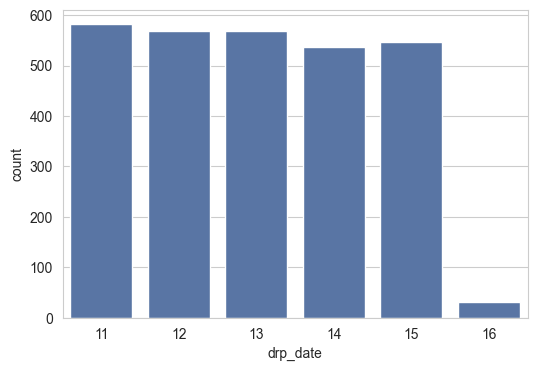

In [45]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_date")
plt.show()

#### Feature Drop Weekday

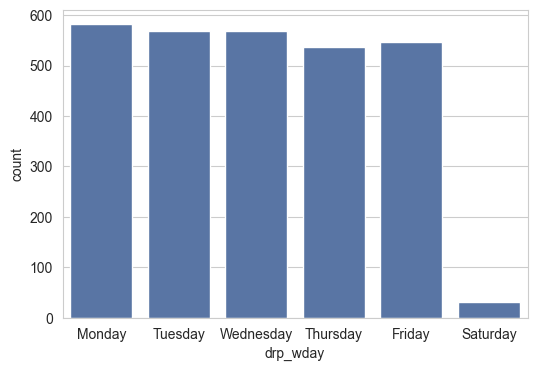

In [46]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_wday")
plt.show()

#### Feature Drop Hour

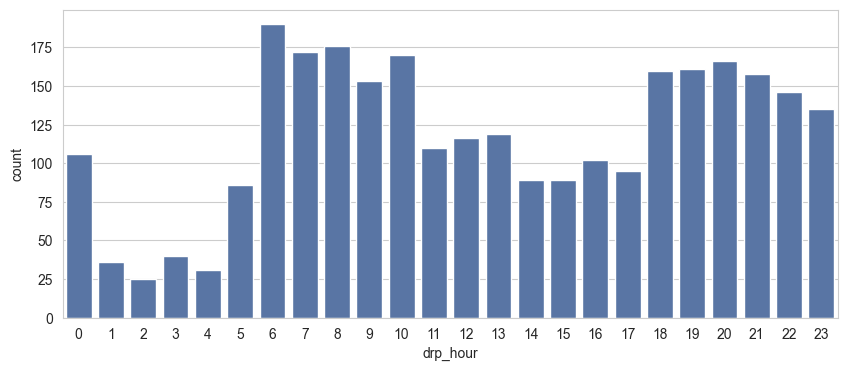

In [47]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="drp_hour")
plt.show()

#### Feature Time Difference

In [48]:
ub_df["time_diff"].dt.total_seconds().describe().to_frame().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
time_diff,2831.00,3144.83,831.04,1247.00,2460.00,3125.00,3840.00,4980.00


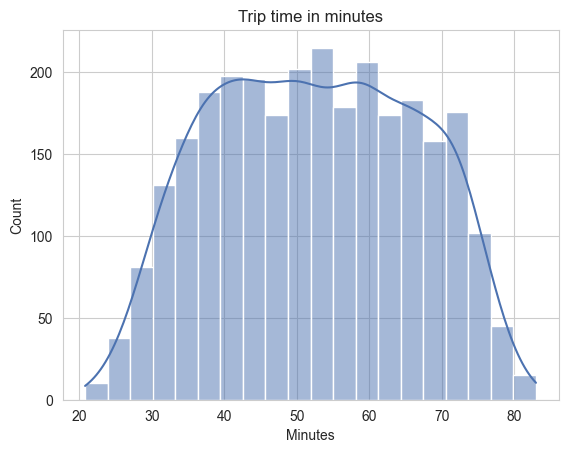

In [49]:
sns.histplot(x=ub_df["time_diff"].dt.total_seconds() / 60, kde=True)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

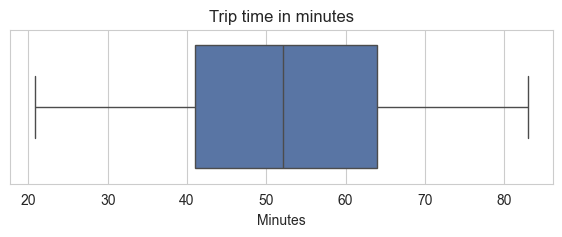

In [50]:
plt.figure(figsize=(7, 2))
sns.boxplot(x=ub_df["time_diff"].dt.total_seconds() / 60)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

In [51]:
# rd_pt = pd.crosstab(index=ub_df["req_hour"], columns=ub_df["drp_hour"])

# plt.figure(figsize=[12, 10])
# sns.heatmap(rd_pt, cmap="YlGnBu", linecolor="white", linewidth=1, annot=True, fmt=".0f")
# plt.show()

In [52]:
# mask = ~ub_df["drp_hour"].isna()
# rd_pt = ub_df[mask].pivot_table(index="req_hour", columns="drp_hour")
# rd_pt  # Request Drop Pivot table.

#### Feature Daily Cancellation Rate

Frequency of booking requests getting canceled daily between 11th and 15th.

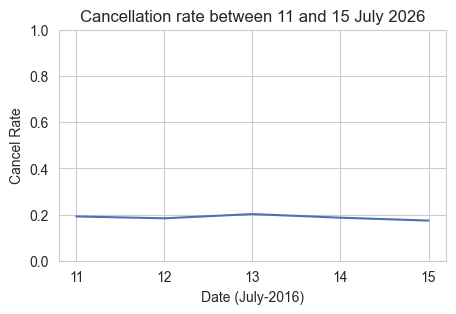

In [53]:
plt.figure(figsize=(5, 3))

sns.lineplot(data=dlm_df, x="req_date", y="cancel_rate")
plt.title("Cancellation rate between 11 and 15 July 2026")
plt.xlabel("Date (July-2016)")
plt.ylabel("Cancel Rate")
plt.xticks(range(11, 16))
plt.yticks(np.arange(0, 1.1, 0.2))

plt.show()

#### Feature Weekly Cancellation Rate

Days of week in which the cancellation rate is maximum.

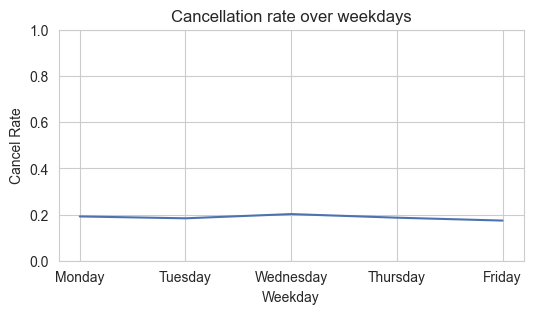

In [54]:
plt.figure(figsize=(6, 3))

sns.lineplot(data=wkm_df, x="req_wday", y="cancel_rate")
plt.title("Cancellation rate over weekdays")
plt.xlabel("Weekday")
plt.ylabel("Cancel Rate")
plt.yticks(np.arange(0, 1.1, 0.2))

plt.show()

#### Feature Hourly Cancellation Rate

Frequency of booking requests getting canceled every hour.

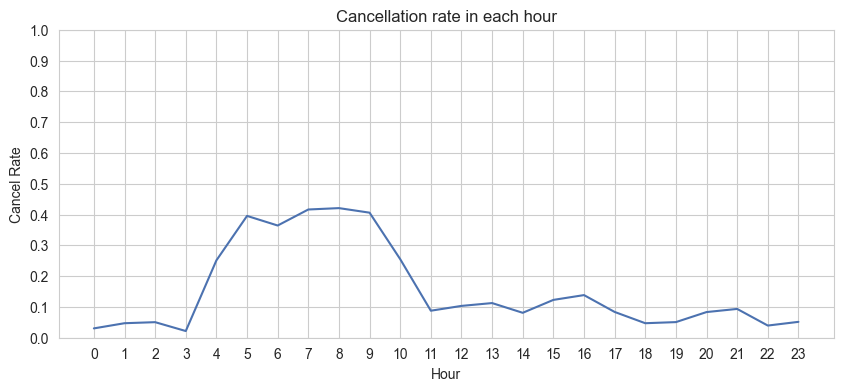

In [104]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="cancel_rate")
plt.title("Cancellation rate in each hour")
plt.xlabel("Hour")
plt.ylabel("Cancel Rate")
plt.xticks(range(0, 24))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.show()

#### Feature Hourly Demand-Supply-Gap

Time of day when the demand is highest and supply is low.

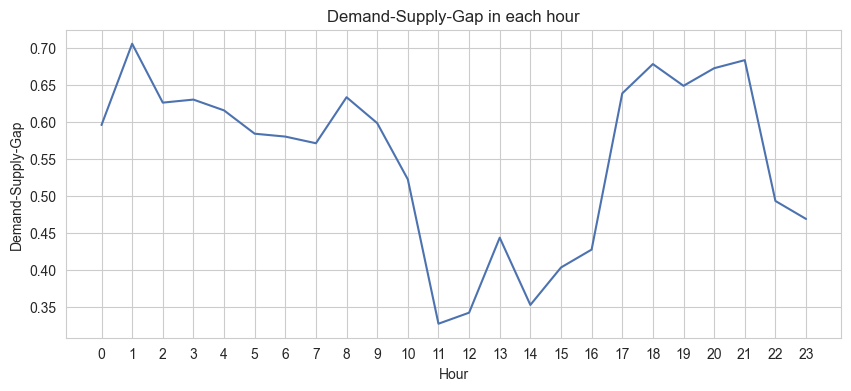

In [56]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="ds_gap")
plt.title("Demand-Supply-Gap in each hour")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

#### Feature Hourly Availability Rate

Time of day when the cabs are available but demand is low.

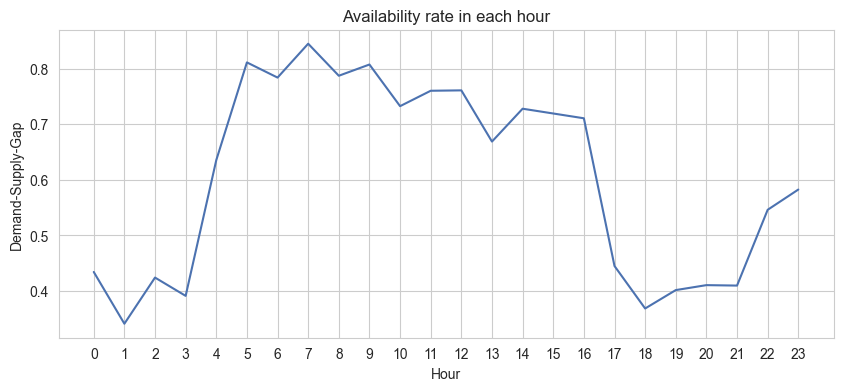

In [57]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="avblty_rate")
plt.title("Availability rate in each hour")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

## 6 Bivariate Analysis

### 6.1 Categorical vs Categorical

#### Features `pickup` vs `status`

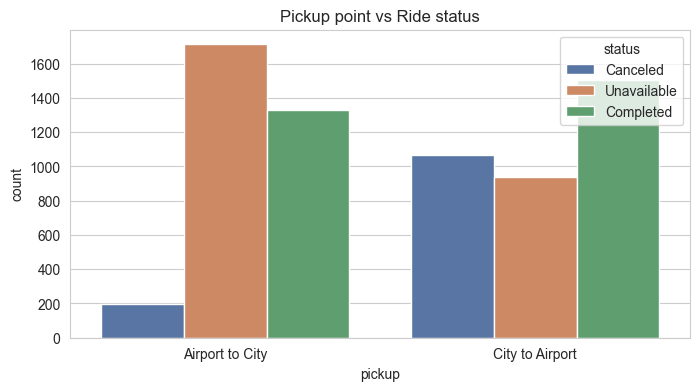

In [58]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ub_df, x="pickup", hue="status")
plt.title("Pickup point vs Ride status")
plt.show()

### 6.2 Numerical vs Categorical

#### Features `req_date` vs `status`

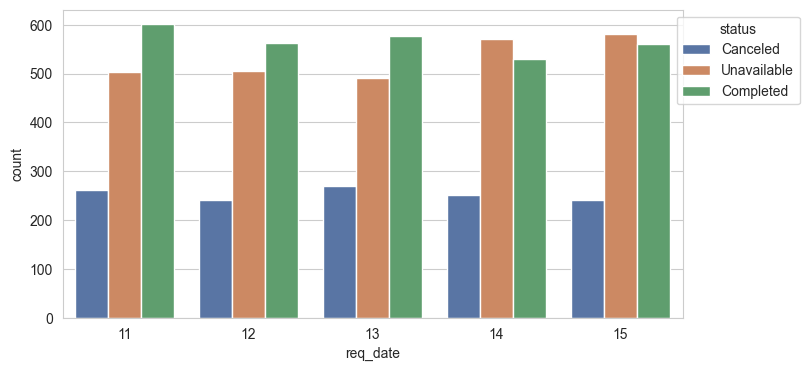

In [59]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=ub_df, x="req_date", hue="status")
ax.legend(title="status", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

In [60]:
rdate_status_ct = pd.crosstab(index=ub_df["req_date"], columns=ub_df["status"])
rdate_status_ct

status,Canceled,Unavailable,Completed
req_date,,,
11,262,504,601
12,240,505,562
13,270,490,577
14,252,571,530
15,240,580,561


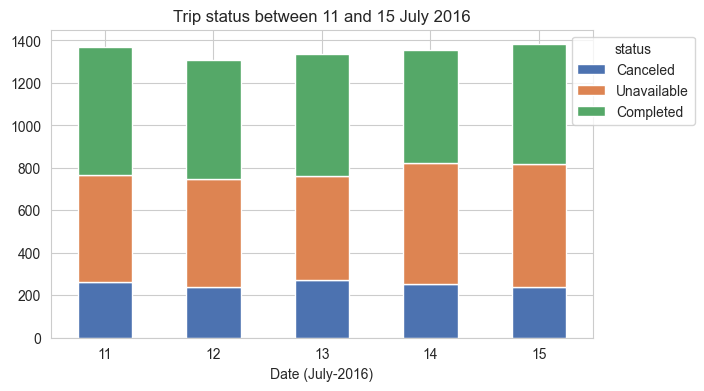

In [61]:
ax = rdate_status_ct.plot(kind="bar", stacked=True, figsize=(7, 4))
ax.legend(title="status", loc="upper right", bbox_to_anchor=(1.2, 1))

plt.title("Trip status between 11 and 15 July 2016")
plt.xlabel("Date (July-2016)")
plt.xticks(rotation=0)

plt.show()

#### Features `req_date` vs `pickup`

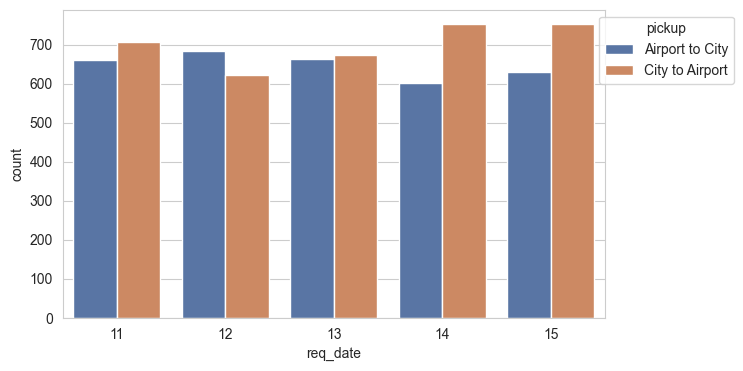

In [113]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=ub_df, x="req_date", hue="pickup")
ax.legend(title="pickup", loc="upper right", bbox_to_anchor=(1.25, 1))
plt.show()

#### Features `req_wday` vs `status`

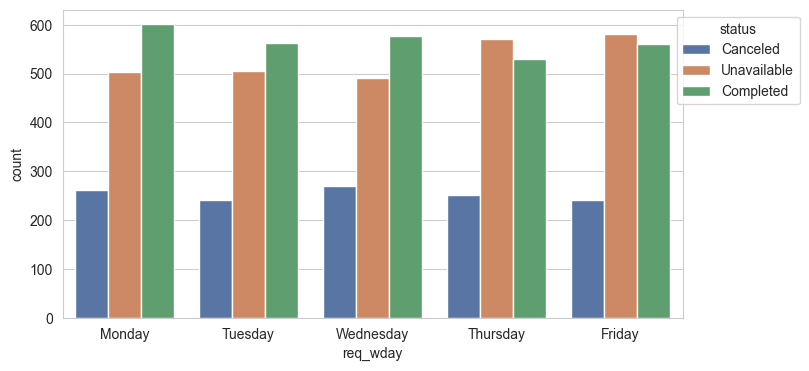

In [115]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=ub_df, x="req_wday", hue="status", order=weekdays)
ax.legend(title="status", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

In [64]:
rwday_status_ct = pd.crosstab(index=ub_df["req_wday"], columns=ub_df["status"]).reindex(weekdays)
rwday_status_ct

status,Canceled,Unavailable,Completed
req_wday,,,
Monday,262,504,601
Tuesday,240,505,562
Wednesday,270,490,577
Thursday,252,571,530
Friday,240,580,561


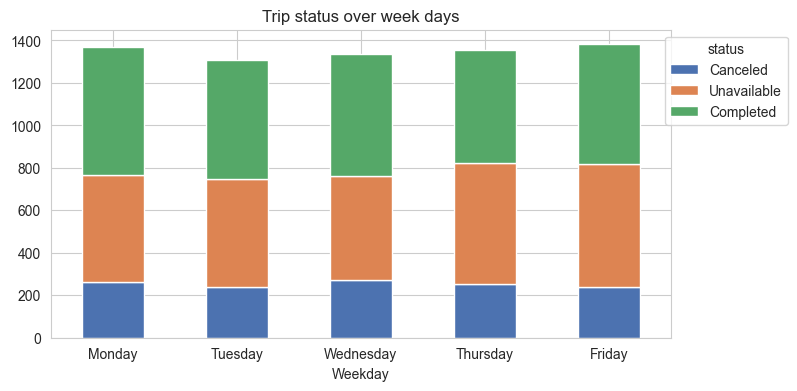

In [65]:
ax = rwday_status_ct.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.legend(title="status", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.title("Trip status over week days")
plt.xlabel("Weekday")
plt.xticks(rotation=0)

plt.show()

#### Features `req_wday` vs `pickup`

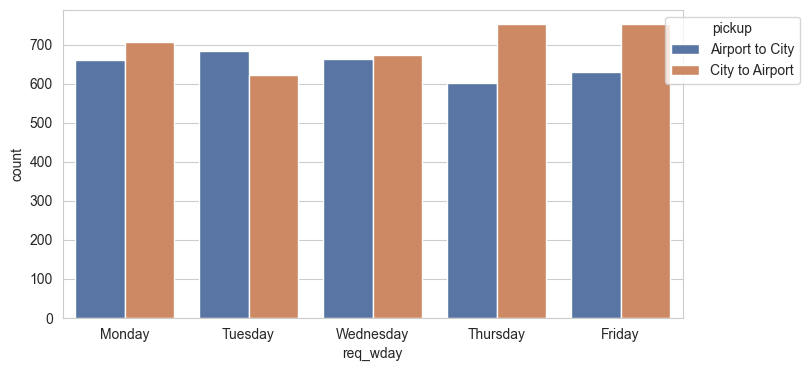

In [117]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=ub_df, x="req_wday", hue="pickup", order=weekdays)
ax.legend(title="pickup", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

#### Features `req_hour` vs `status`

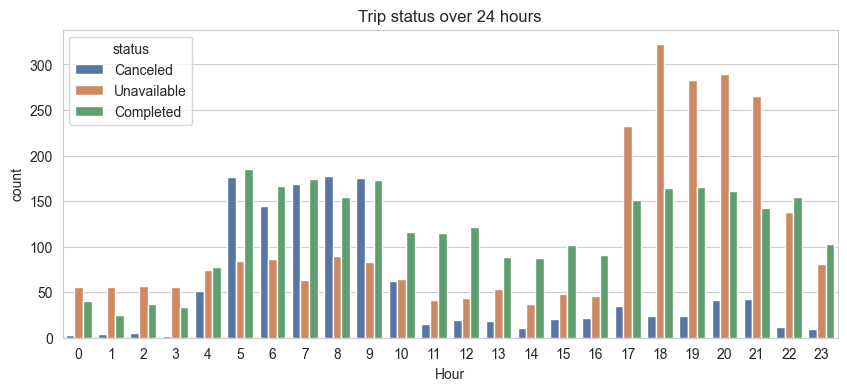

In [67]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_hour", hue="status")
plt.title("Trip status over 24 hours")
plt.xlabel("Hour")
plt.show()

In [68]:
rs_ct = pd.crosstab(index=ub_df["req_hour"], columns=ub_df["status"])
# rs_ct

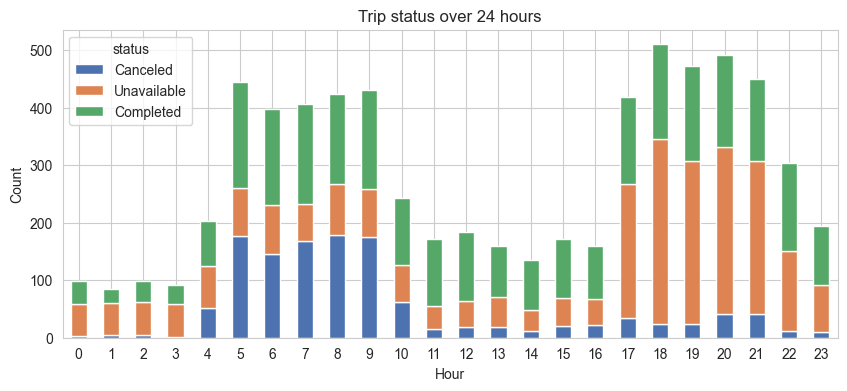

In [69]:
ax = rs_ct.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Trip status over 24 hours")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#### Features `req_hour` vs `pickup`

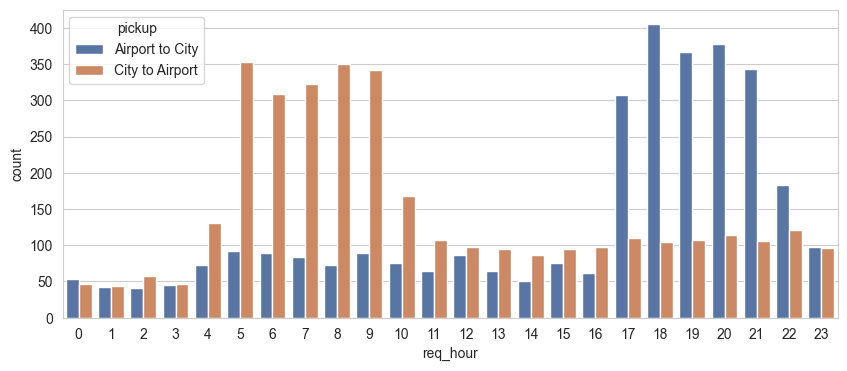

In [70]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_hour", hue="pickup")
plt.show()

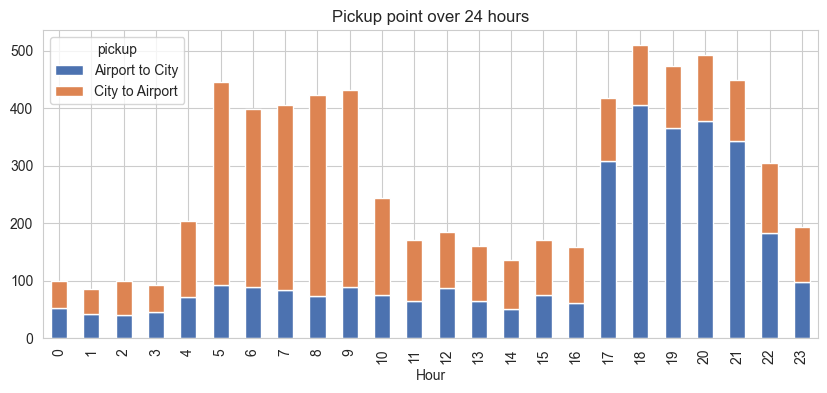

In [71]:
rp_ct = pd.crosstab(index=ub_df["req_hour"], columns=ub_df["pickup"])

ax = rp_ct.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Pickup point over 24 hours")
plt.xlabel("Hour")

plt.show()

#### Features `day_type` vs `status`

In [72]:
dtype_st_ct = pd.crosstab(index=ub_df["day_type"], columns=ub_df["status"])
dtype_st_ct

status,Canceled,Unavailable,Completed
day_type,,,
Mid Night,65,299,214
Early Morning,668,323,681
Working Hours,402,971,1210
Night,129,1057,726


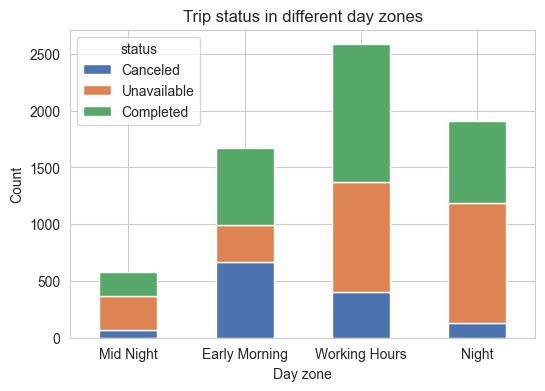

In [73]:
ax = dtype_st_ct.plot(kind="bar", stacked=True, figsize=(6, 4))
plt.title("Trip status in different day zones")
plt.xlabel("Day zone")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#### Features `day_type` vs `pickup`

In [74]:
dtype_pk_ct = pd.crosstab(index=ub_df["day_type"], columns=ub_df["pickup"])
dtype_pk_ct

pickup,Airport to City,City to Airport
day_type,,
Mid Night,253,325
Early Morning,337,1335
Working Hours,1280,1303
Night,1368,544


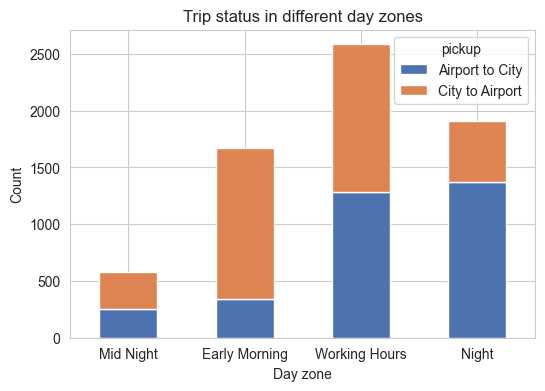

In [75]:
ax = dtype_pk_ct.plot(kind="bar", stacked=True, figsize=(6, 4))
plt.title("Trip status in different day zones")
plt.xlabel("Day zone")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#### Features `drp_date` vs `status`

In [76]:
# plt.figure(figsize=(6, 4))
# sns.countplot(data=ub_df, x="drp_date", hue="status")
# plt.show()

#### Features `drp_date` vs `pickup`

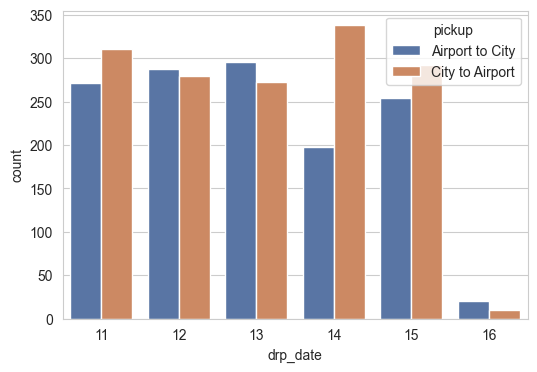

In [77]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_date", hue="pickup")
plt.show()

#### Features `drp_wday` vs `pickup`

In [78]:
# plt.figure(figsize=(6, 4))
# sns.countplot(data=ub_df, x="drp_wday", hue="status")
# plt.show()

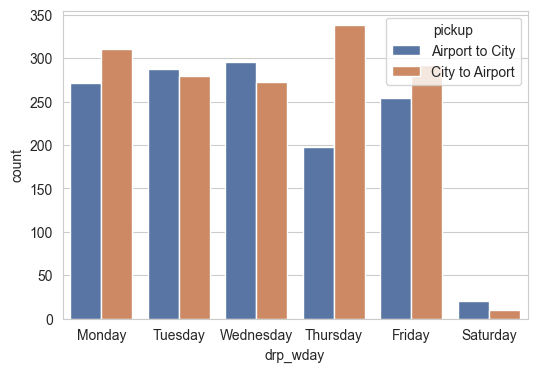

In [79]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_wday", hue="pickup")
plt.show()

#### Features `drp_hour` vs `status`

In [80]:
# plt.figure(figsize=(10, 4))
# sns.countplot(data=ub_df, x="drp_hour", hue="status")
# plt.show()

#### Features `drp_hour` vs `pickup`

In [81]:
# plt.figure(figsize=(10, 4))
# sns.countplot(data=ub_df, x="drp_hour", hue="pickup")
# plt.show()

#### Features `time_diff` vs `status`

In [82]:
# sns.histplot(x=ub_df["time_diff"].dt.total_seconds() / 60, hue=ub_df["status"], kde=True)
# plt.title("Trip time in minutes")
# plt.xlabel("Minutes")
# plt.show()

#### Features `time_diff` vs `pickup`

In [83]:
ub_df["time_diff"].dt.total_seconds().describe().to_frame().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
time_diff,2831.00,3144.83,831.04,1247.00,2460.00,3125.00,3840.00,4980.00


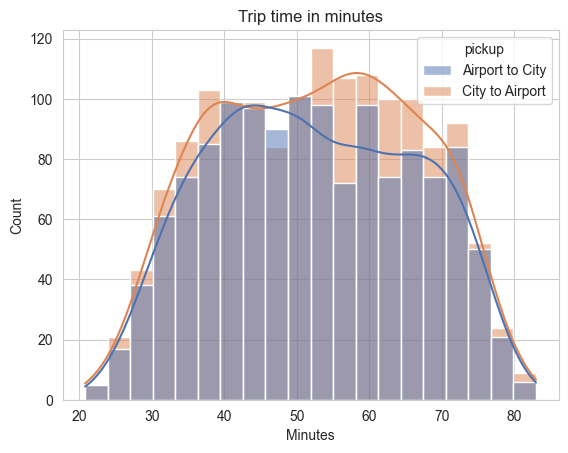

In [84]:
sns.histplot(x=ub_df["time_diff"].dt.total_seconds() / 60, hue=ub_df["pickup"], kde=True)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

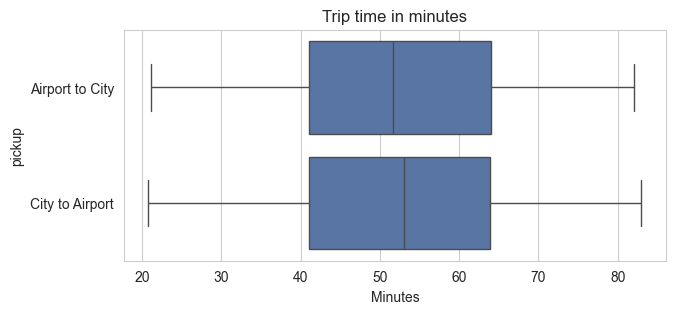

In [85]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=ub_df["time_diff"].dt.total_seconds() / 60, y=ub_df["pickup"])
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

### 6.3 Numerical vs Numerical

#### Features `avblty_rate` vs `cancel_rate`

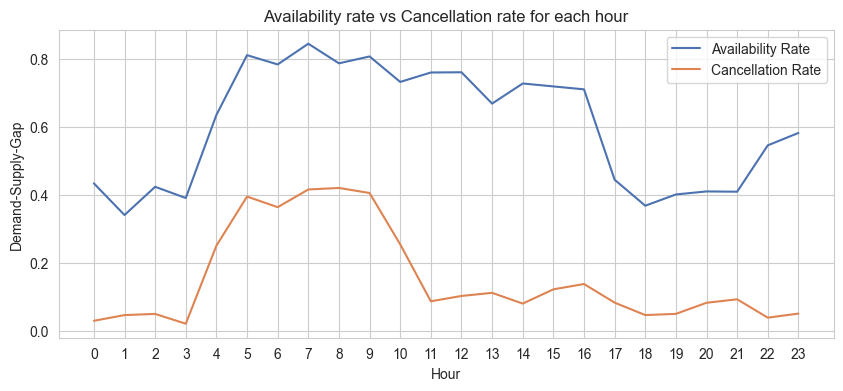

In [86]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="avblty_rate", label="Availability Rate")
sns.lineplot(data=hrm_df, x="req_hour", y="cancel_rate", label="Cancellation Rate")
plt.title("Availability rate vs Cancellation rate for each hour")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

## 7 Multivariate Analysis

#### Features `req_hour` vs `pickup` vs `status`

In [87]:
rhr_ps_ct = pd.crosstab(index=ub_df["req_hour"], columns=[ub_df["pickup"], ub_df["status"]])
rhr_ps_ct

pickup   Airport to City                       City to Airport              \
status          Canceled Unavailable Completed        Canceled Unavailable   
req_hour                                                                     
0                      0          30        23               3          26   
1                      0          29        13               4          27   
2                      0          25        16               5          32   
3                      0          30        15               2          26   
4                      2          34        36              49          40   
5                      4           3        85             172          81   
6                      4           4        81             141          82   
7                      5           3        75             164          60   
8                      2           4        67             176          86   
9                      8           7        74             167          76   
10                     9          13        53              53          52   
11                     5          10        49              10          31   
12                    10          14        63               9          30   
13                     9          21        35               9          32   
14                     6           7        37               5          30   
15                    11          13        52              10          35   
16                    14           9        38               8          37   
17                    19         215        74              16          17   
18                    15         309        81               9          13   
19                    15         268        83               9          15   
20                    29         275        74              12          15   
21                    28         254        61              14          11   
22                     3         100        80               9          38   
23                     0          36        62              10          45   

pickup              
status   Completed  
req_hour            
0               17  
1               12  
2               21  
3               19  
4               42  
5              100  
6               86  
7               99  
8               88  
9               99  
10              63  
11              66  
12              58  
13              54  
14              51  
15              50  
16              53  
17              77  
18              83  
19              83  
20              87  
21              81  
22              74  
23              41

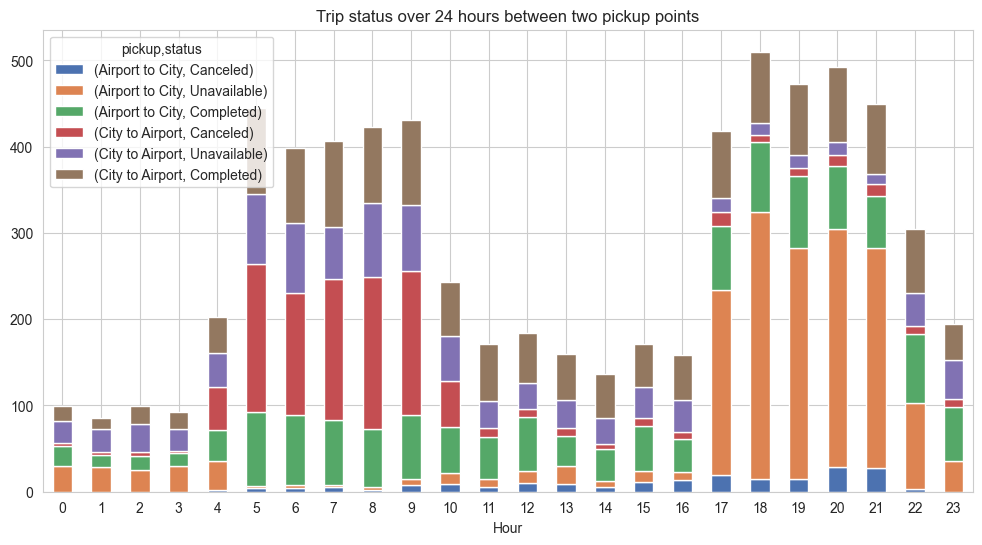

In [88]:
ax = rhr_ps_ct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Trip status over 24 hours between two pickup points")
plt.xlabel("Hour")
plt.xticks(rotation=0)

plt.show()

#### Features `day_type` vs `pickup` vs `status`

In [89]:
dtype_pk_st_ct = pd.crosstab(index=ub_df["day_type"], columns=[ub_df["pickup"], ub_df["status"]])
dtype_pk_st_ct

pickup        Airport to City                       City to Airport  \
status               Canceled Unavailable Completed        Canceled   
day_type                                                              
Mid Night                   2         148       103              63   
Early Morning              15          14       308             653   
Working Hours             106         618       556             296   
Night                      75         933       360              54   

pickup                               
status        Unavailable Completed  
day_type                             
Mid Night             151       111  
Early Morning         309       373  
Working Hours         353       654  
Night                 124       366

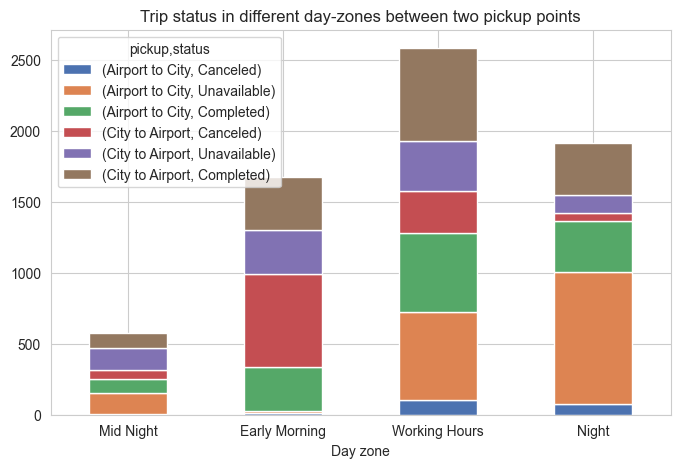

In [90]:
ax = dtype_pk_st_ct.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Trip status in different day-zones between two pickup points")
plt.xlabel("Day zone")
plt.xticks(rotation=0)

plt.show()

#### Features `req_wday` vs `pickup` vs `status`

In [91]:
rwd_ps_ct = pd.crosstab(
    index=ub_df["req_wday"],
    columns=[ub_df["pickup"], ub_df["status"]],
).reindex(weekdays)
rwd_ps_ct

pickup    Airport to City                       City to Airport              \
status           Canceled Unavailable Completed        Canceled Unavailable   
req_wday                                                                      
Monday                 42         338       281             220         166   
Tuesday                45         350       289             195         155   
Wednesday              48         317       298             222         173   
Thursday               32         378       191             220         193   
Friday                 31         330       268             209         250   

pickup               
status    Completed  
req_wday             
Monday          320  
Tuesday         273  
Wednesday       279  
Thursday        339  
Friday          293

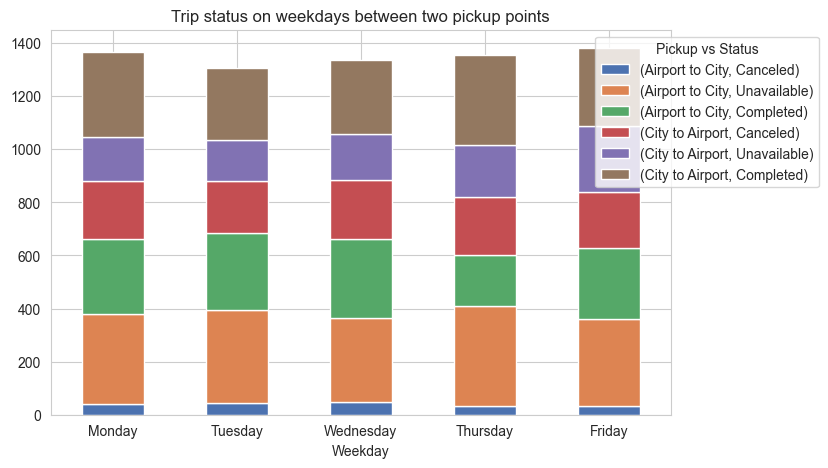

In [92]:
ax = rwd_ps_ct.plot(kind="bar", stacked=True, figsize=(8, 5))
ax.legend(title="Pickup vs Status", loc="upper right", bbox_to_anchor=(1.25, 1))

plt.title("Trip status on weekdays between two pickup points")
plt.xlabel("Weekday")
plt.xticks(rotation=0)

plt.show()

In [94]:
mask1 = ub_df["pickup"] == "Airport to City"
air_df = caculate_metrics(ub_df[mask1], "req_hour")

mask2 = ub_df["pickup"] == "City to Airport"
cty_df = caculate_metrics(ub_df[mask2], "req_hour")

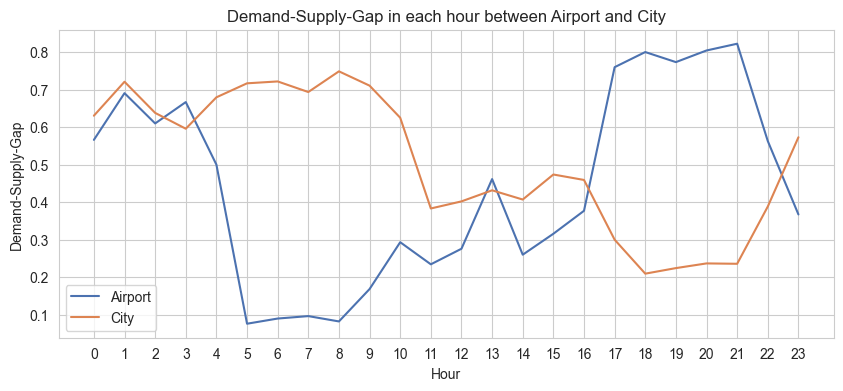

In [95]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=air_df, x="req_hour", y="ds_gap", label="Airport")
sns.lineplot(data=cty_df, x="req_hour", y="ds_gap", label="City")
plt.title("Demand-Supply-Gap in each hour between Airport and City")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

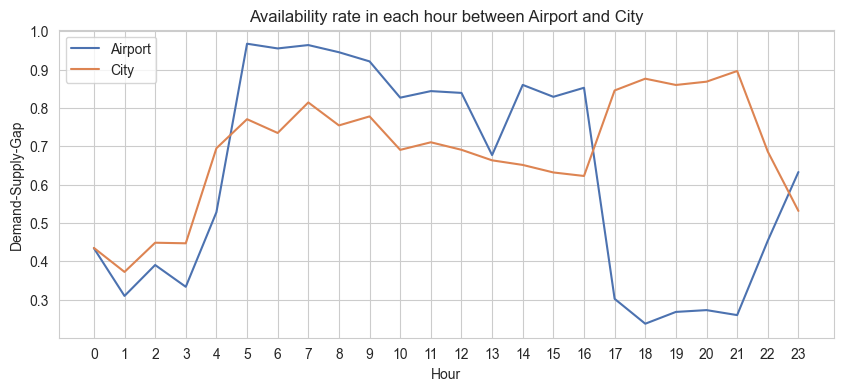

In [96]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=air_df, x="req_hour", y="avblty_rate", label="Airport")
sns.lineplot(data=cty_df, x="req_hour", y="avblty_rate", label="City")
plt.title("Availability rate in each hour between Airport and City")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

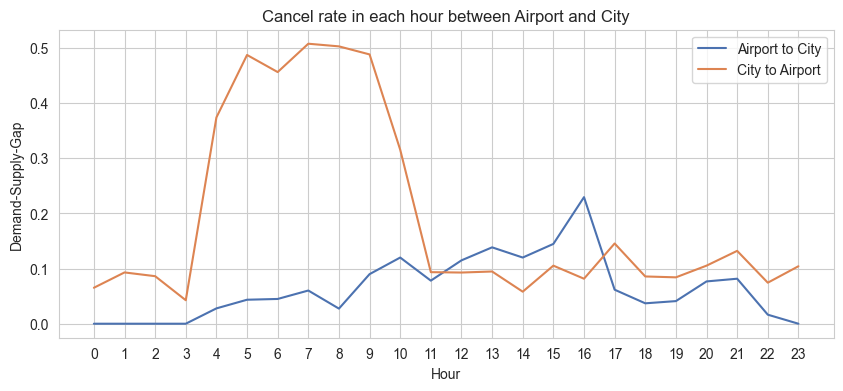

In [98]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=air_df, x="req_hour", y="cancel_rate", label="Airport to City")
sns.lineplot(data=cty_df, x="req_hour", y="cancel_rate", label="City to Airport")
plt.title("Cancel rate in each hour between Airport and City")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

## 8 Root Cause Analysis

In [101]:
424 - (155 + 140)

129